# **DM Python pour la Datascience**

### Installation des packages nécessaires

In [1]:
%pip install -q great_tables
%pip install -q cartiflette
%pip install -q great_tables
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Import des packages

In [2]:
import pandas as pd
from great_tables import GT, style, loc,md
from graphiques_surrepresentation import plot_carte_surrepresentation, plot_surrepresentation
import warnings
warnings.filterwarnings('ignore')

### Import du jeu de données

In [3]:
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## 1. Explorations générales
### Question 1

Créer ou mettre à jour les variables suivantes:
• code_commune: En utilisant la variable déjà existante et le département, remplacer la valeur code_commune pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.
• candidat: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.

In [4]:
df['code_commune'] = df['code_departement'].astype(str) + df['code_commune'].astype(str).str.zfill(3)
df.head()

df['candidat'] = df['prenom'] + ' ' + df['nom']
df.tail()


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
528670,fr_etranger,Français établis hors de France,fr_etranger229,Zurich,NaN,nuls,31,NaN
528671,fr_etranger,Français établis hors de France,fr_etranger231,Taipei,NaN,nuls,2,NaN
528672,fr_etranger,Français établis hors de France,fr_etranger233,Nour-Soultan,NaN,nuls,0,NaN
528673,fr_etranger,Français établis hors de France,fr_etranger234,Monterrey,NaN,nuls,2,NaN
528674,fr_etranger,Français établis hors de France,fr_etranger235,Bahamas (Nassau),NaN,nuls,0,NaN


### Question 2
Compléter la phrase suivante grâce à Python:
En 2022, il y avait XXXXX candidats à l’élection présidentielle
Note: Attention aux votes non exprimés et aux abstentions

In [5]:
nombre_candidats = df['candidat'].nunique()
print(f"En 2022, il y avait {nombre_candidats} candidats à l’élection présidentielle.")

En 2022, il y avait 12 candidats à l’élection présidentielle.


### Question 3

Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’estàdire en retirant abstentions et votes non exprimés).
Représenter cela dans un dataframe ou, pour avoir tous les points, dans un tableau mis en forme via great_tables (il n’est pas obligatoire d’aller aussi loin dans la mise en forme mais essayez d’obtenir un beau tableau tout de même).
Note: vous pouvez contrôler vos résultats obtenus avec cette page

In [6]:
scores_nationaux = df.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux['pourcentage'] = (scores_nationaux['voix'] / scores_nationaux['voix'].sum()) * 100
scores_nationaux = scores_nationaux.sort_values(by='voix', ascending=False)
scores_nationaux.head()


,candidat,voix,pourcentage
1,Emmanuel MACRON,9783058,27.845822
5,Marine LE PEN,8133828,23.151568
4,Jean-Luc MÉLENCHON,7712520,21.952386
11,Éric ZEMMOUR,2485226,7.073776
9,Valérie PÉCRESSE,1679001,4.778993


In [7]:
scores_nationaux = df.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux['pourcentage'] = (scores_nationaux['voix'] / scores_nationaux['voix'].sum()) * 100
scores_nationaux = scores_nationaux.sort_values(by='voix', ascending=False).reset_index(drop=True)


scores_nationaux.insert(0, 'rang', range(1, len(scores_nationaux) + 1))

scores_nationaux['voix_fmt'] = scores_nationaux['voix'].apply(lambda x: f"{x:,.0f}".replace(",", " "))
scores_nationaux['pct_fmt'] = scores_nationaux['pourcentage'].apply(lambda x: f"{x:.2f} %")

(
    GT(scores_nationaux[["candidat", "voix_fmt", "pct_fmt"]])
    .tab_header(title=md("**Elections**"), subtitle="Résultats du premier tour (📅 10 avril 2022)")
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.title())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.subtitle())
    .cols_label(candidat="Candidat", voix_fmt="Nombre votes (total)", pct_fmt="Score (% votes exprimés)")
)


GT(_tbl_data=                 candidat   voix_fmt  pct_fmt
0         Emmanuel MACRON  9 783 058  27.85 %
1           Marine LE PEN  8 133 828  23.15 %
2      Jean-Luc MÉLENCHON  7 712 520  21.95 %
3            Éric ZEMMOUR  2 485 226   7.07 %
4        Valérie PÉCRESSE  1 679 001   4.78 %
5           Yannick JADOT  1 627 853   4.63 %
6           Jean LASSALLE  1 101 387   3.13 %
7          Fabien ROUSSEL    802 422   2.28 %
8   Nicolas DUPONT-AIGNAN    725 176   2.06 %
9            Anne HIDALGO    616 478   1.75 %
10        Philippe POUTOU    268 904   0.77 %
11       Nathalie ARTHAUD    197 094   0.56 %, _body=<great_tables._gt_data.Body object at 0x7efef07cda90>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='pct_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7efef07cd6a0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Elections**'), subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7efef07cdfd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7efef092a990>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=0, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=1, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=2, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=3, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=4, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=5, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=6, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=7, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, 

## 2. Comparaison des scores départements aux moyennes nationales.
### Question 4

Créer un dataframe nommé score_departements stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

In [8]:
score_departements = df.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
score_departements['score'] = (score_departements['voix'] / score_departements.groupby('code_departement')['voix'].transform('sum')) * 100
score_departements= score_departements.rename(columns={"voix": "votes"})

score_departement_11 = score_departements[score_departements['code_departement'] == "11"].sort_values(by='score', ascending=False).reset_index(drop=True)
score_departement_11["score"] = score_departement_11["score"].apply(lambda x: f"{x:.2f} %")

(
    GT(score_departement_11[["code_departement", "candidat", "votes", "score"]])
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())

)

code_departement,candidat,votes,score
11,Marine LE PEN,64027,30.14 %
11,Emmanuel MACRON,43104,20.29 %
11,Jean-Luc MÉLENCHON,42039,19.79 %
11,Éric ZEMMOUR,18434,8.68 %
11,Jean LASSALLE,12382,5.83 %
11,Valérie PÉCRESSE,7350,3.46 %
11,Yannick JADOT,6322,2.98 %
11,Anne HIDALGO,6166,2.90 %
11,Fabien ROUSSEL,5622,2.65 %
11,Nicolas DUPONT-AIGNAN,4206,1.98 %


### Question 5
Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce dataframe score_departements, nous allons le réutiliser par la suite.

In [9]:
score_departements = score_departements.merge(scores_nationaux[['candidat', 'voix', 'pourcentage']],
                                              on='candidat',
                                              how='left')

score_departements = score_departements.rename(columns={"votes": "votes_departement",
                                                        "score":"score_departement",
                                                        "voix": "votes_national",
                                                        "pourcentage": "score_national"})

score_departement_11 = score_departements[score_departements['code_departement'] == "11"].sort_values(by='score_departement', ascending=False).reset_index(drop=True)
score_departement_11["score_departement"] = score_departement_11["score_departement"].apply(lambda x: f"{x:.2f} %")
score_departement_11["score_national"] = score_departement_11["score_national"].apply(lambda x: f"{x:.2f} %")


score_departement_11.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
1,11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
2,11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
3,11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
4,11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


In [10]:
(
    GT(score_departement_11[["code_departement", "candidat", "votes_departement", "score_departement", "votes_national", "score_national"]].head(5))
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
)

code_departement,candidat,votes_departement,score_departement,votes_national,score_national
11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


### Question 6
Créer une variable surrepresentation qui compare, en relatif, les scores nationaux et départe mentaux.
Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de surrepresentation sera égale à 100 (%).

In [11]:
score_departements['surrepresentation'] = ((score_departements['score_departement'] - score_departements['score_national']) * 100/ score_departements['score_national'])
score_departements.head(20)

print(score_departements[score_departements['code_departement'] == "08"])

   code_departement               candidat  votes_departement  \
84               08           Anne HIDALGO               1741   
85               08        Emmanuel MACRON              31656   
86               08         Fabien ROUSSEL               3009   
87               08          Jean LASSALLE               4084   
88               08     Jean-Luc MÉLENCHON              22281   
89               08          Marine LE PEN              48242   
90               08       Nathalie ARTHAUD               1081   
91               08  Nicolas DUPONT-AIGNAN               2957   
92               08        Philippe POUTOU               1112   
93               08       Valérie PÉCRESSE               5556   
94               08          Yannick JADOT               3446   
95               08           Éric ZEMMOUR               8771   

    score_departement  votes_national  score_national  surrepresentation  
84           1.299875          616478        1.754701         -25.920431  
85  

### Question 7
Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des principales surreprésentations (en valeur absolue) par département.

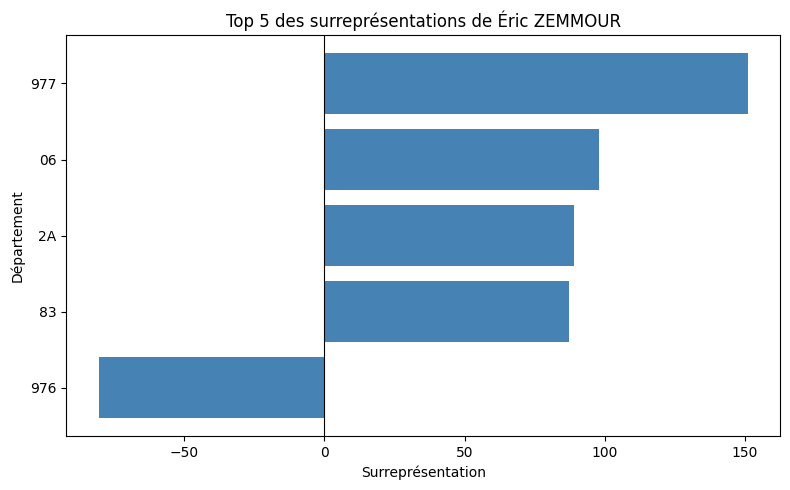

In [12]:
plot_surrepresentation('Éric ZEMMOUR', score_departements)

### Question 8
Faire une fonction permettant de restreindre score_departements en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser score_departements nous allons l’utiliser à nouveau !).
Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.

In [13]:
from cartiflette import carti_download
departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

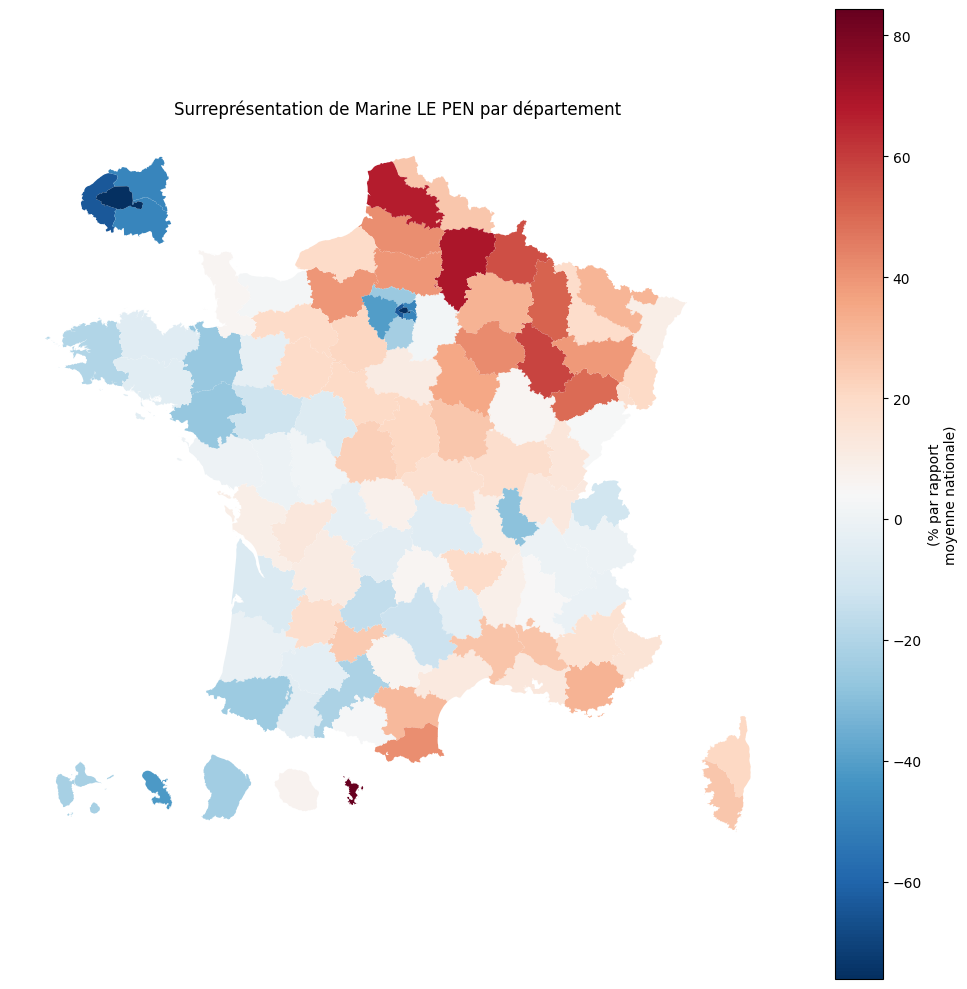

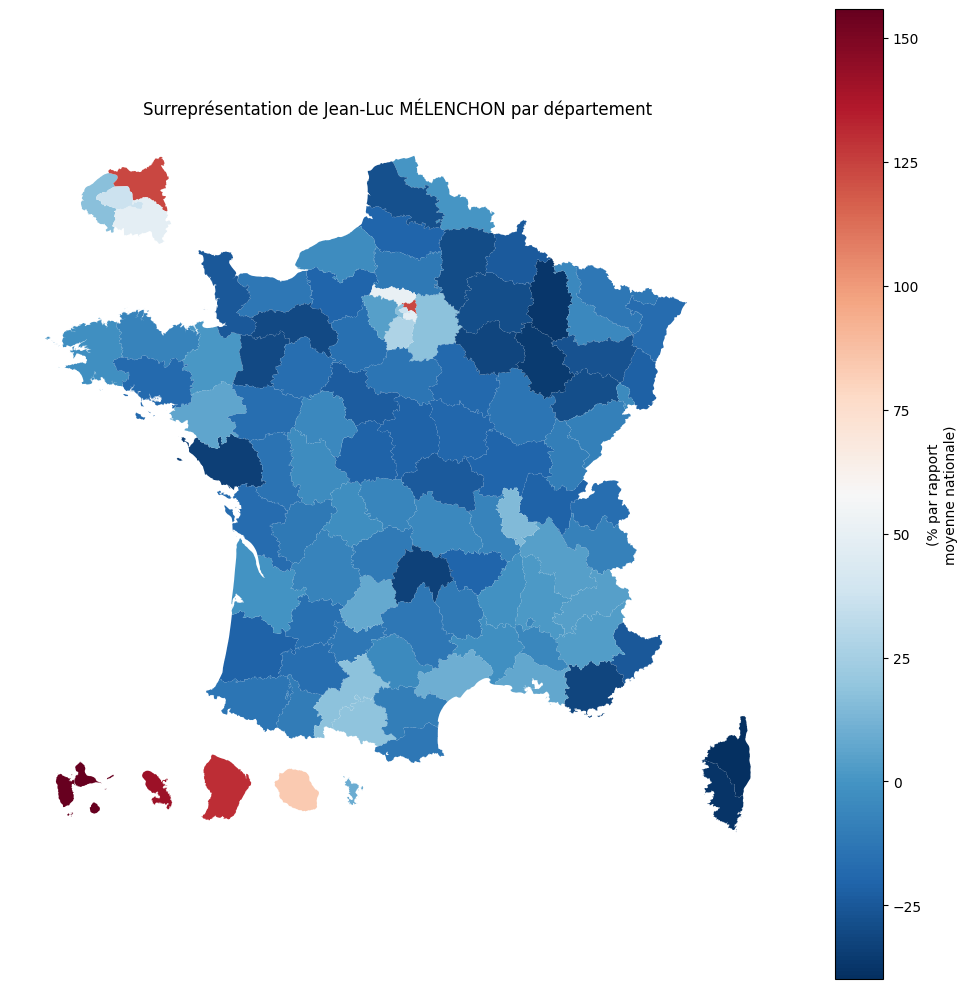

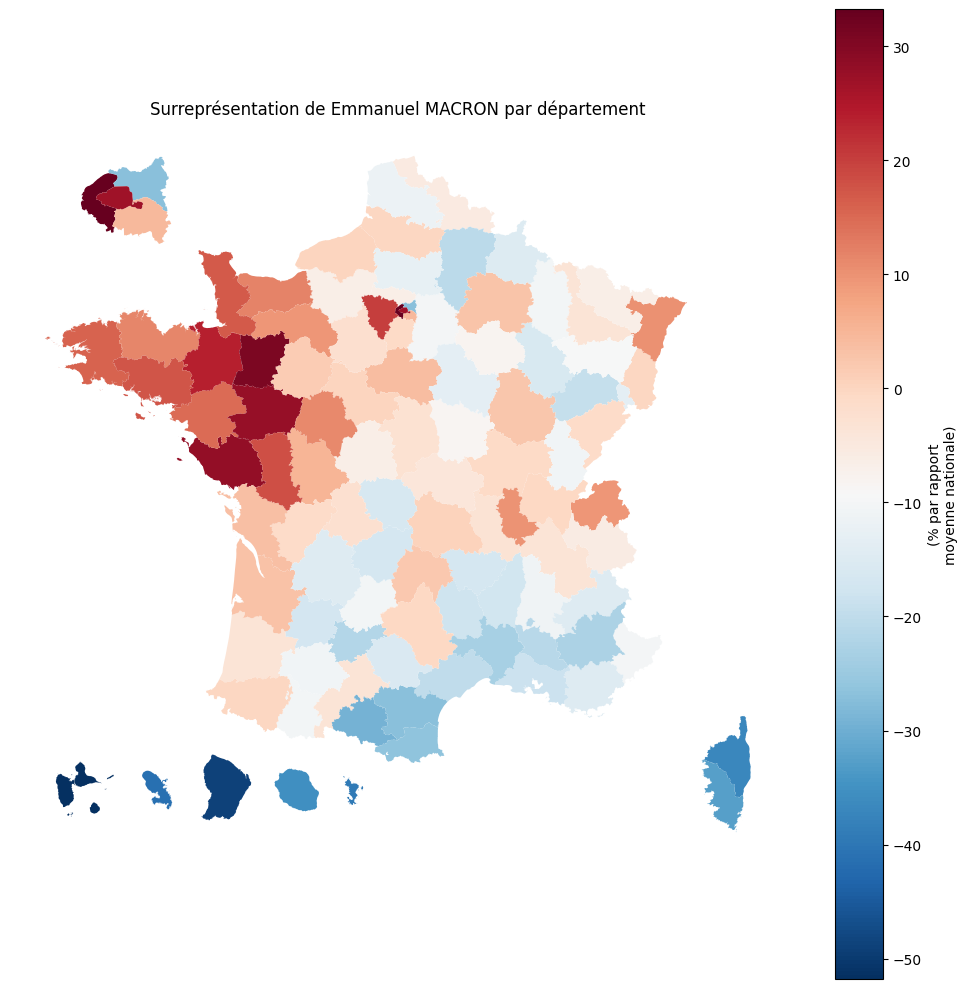

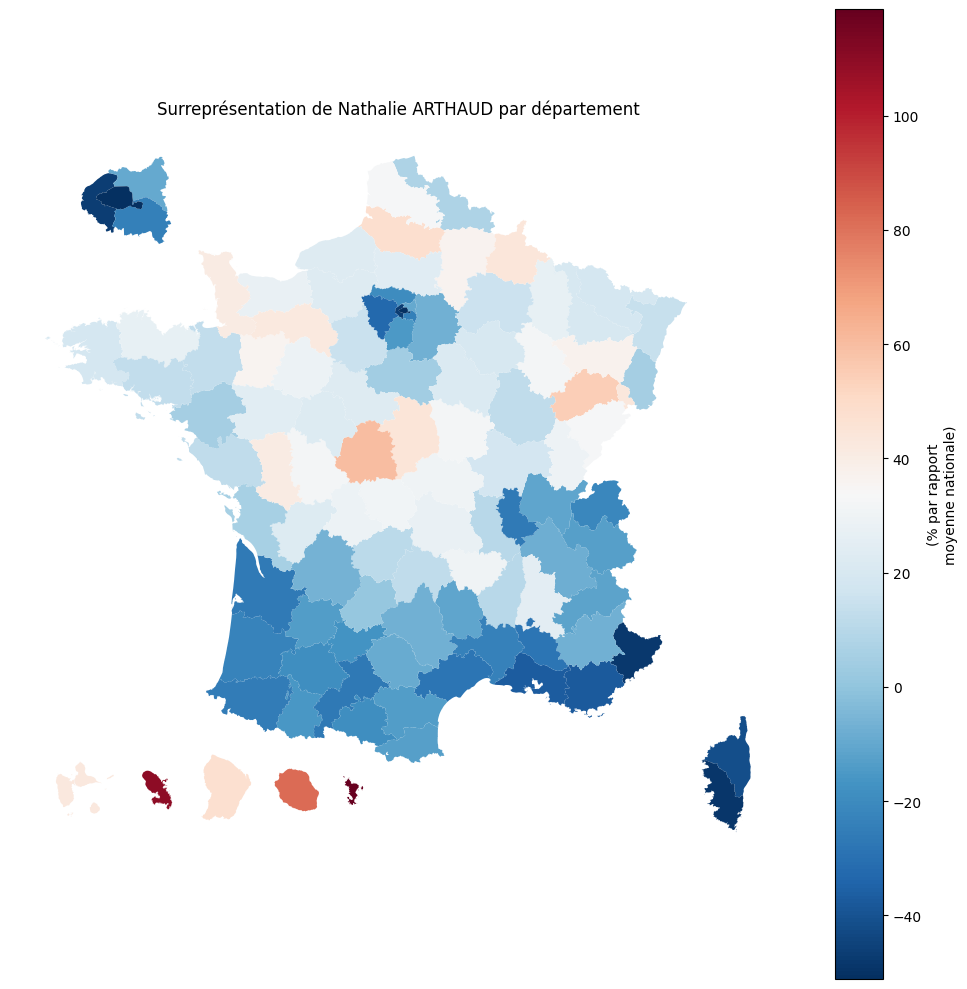

In [14]:
plot_carte_surrepresentation('Marine LE PEN', score_departements, departement_borders)
plot_carte_surrepresentation('Jean-Luc MÉLENCHON', score_departements, departement_borders)
plot_carte_surrepresentation('Emmanuel MACRON', score_departements, departement_borders)
plot_carte_surrepresentation('Nathalie ARTHAUD', score_departements, departement_borders)